#### Experiment 1a
- 1D
- Linear variation - electrode exponenets vary from -1 to -2
- 5 electrodes
- Combined noise
- Average by TS, PSD and SpecMod. Do not produce plots, save outputs
- Load in JSON output summaries and plot a single combined plot

In [2]:
# Imports for functionality 
from dissertation_simulations.time_series import sweep_electrodes_ts_2D
from dissertation_simulations.psd import sweep_electrodes_psd_2D
from dissertation_simulations.spec_mod import sweep_electrodes_specmod_2D
from dissertation_simulations.exponents import generate_spatial_exponent_matrix, generate_2D_exponent_matrix
from dissertation_simulations.plotting import plot_summary_boxplots
from dissertation_simulations.params import electrode_sim_params_full

import numpy as np
import json

from scipy.stats import ttest_rel

In [3]:
exp_matrix = generate_2D_exponent_matrix(grid_shape=(1, 5), exp_range=(-2, -1), gradient_axis="cols")
exp_matrix

array([[-2.  , -1.75, -1.5 , -1.25, -1.  ]])

{'exponent': array([[-2.  , -1.75, -1.5 , -1.25, -1.  ]]), 'psd_average_space': 'linear'}


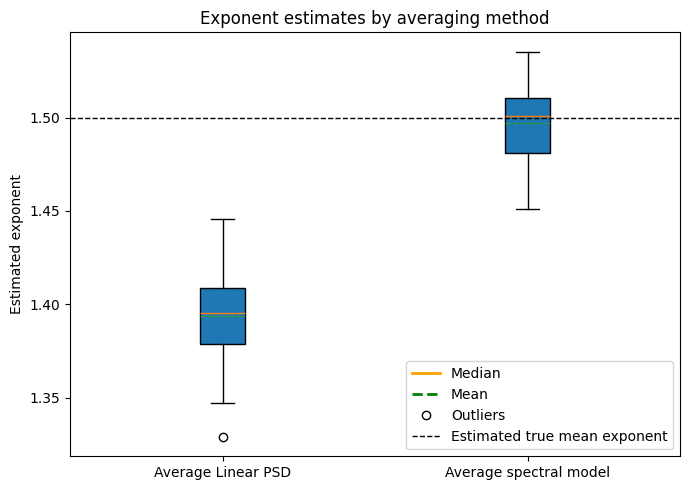

In [4]:
# Average the linear PSD
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_psd_2D(grid_range=[(1, 5)], exponent=exp_matrix, psd_average_space="linear", 
                                                              n_repeats=100, base_params=electrode_sim_params_full, plot=False, return_full=True)

exp1a_result1_psd_linear = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\Combined\exp1aresults1_psd_linear_exp_matrix_cols_-1-2.json", "w") as f:
    json.dump(exp1a_result1_psd_linear, f, indent=4)

# Average the SpecMod
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_specmod_2D(grid_range=[(1, 5)], exponent=exp_matrix, 
                                                              n_repeats=100, base_params=electrode_sim_params_full, plot=False, return_full=True)

exp1a_result2_specmod = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\Combined\exp1aresults2_specmod_exp_matrix_cols_-1-2.json", "w") as f:
    json.dump(exp1a_result2_specmod, f, indent=4)

# Loading summaries and combining into a single plot

summary_paths = [
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\Combined\exp1aresults1_psd_linear_exp_matrix_cols_-1-2.json",
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\Combined\exp1aresults2_specmod_exp_matrix_cols_-1-2.json"
]

labels = [
    "Average Linear PSD",
    "Average spectral model"
]

fig, ax = plot_summary_boxplots(
    summary_paths=summary_paths,
    labels=labels,
    true_mean_exp=np.mean(-exp_matrix)
)

fig.savefig(r"C:\Users\chloe\DissertationSimulations\Figures\1D electrodes\Combined plots\Combined sims\exp1a_combined_plot_1D_exp_matrix_cols_-1-2.png", dpi=300, bbox_inches="tight")

In [5]:
# Paired t-tests
with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\Combined\exp1aresults1_psd_linear_exp_matrix_cols_-1-2.json") as f:
    psd_linear_data = json.load(f)

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\Combined\exp1aresults2_specmod_exp_matrix_cols_-1-2.json") as f:
    spec_data = json.load(f)

psd_linear = np.array(psd_linear_data["all_distributions"][0])
spec = np.array(spec_data["all_distributions"][0])

t, p = ttest_rel(psd_linear, spec)
print(f"PSD - linear averaging vs Spectral model: t = {t:.3f}, p = {p:.5f}")

PSD - linear averaging vs Spectral model: t = -35.816, p = 0.00000


#### Experiment 1b
- 1D
- Linear variation - electrode exponents vary from -1 to -1.5 - "middle out"
- 5 electrodes
- Combined noise
- Average by TS, PSD and SpecMod. Do not produce plots, save outputs
- Load in JSON output summaries and plot a single combined plot

In [6]:
# Define exponent matrix
exp_matrix = generate_spatial_exponent_matrix(grid_shape=(1, 5), exp_min=-1.5, exp_max=-1, pattern="middle")
exp_matrix

array([[-1.  , -1.25, -1.5 , -1.25, -1.  ]])

{'exponent': array([[-1.  , -1.25, -1.5 , -1.25, -1.  ]]), 'psd_average_space': 'linear'}


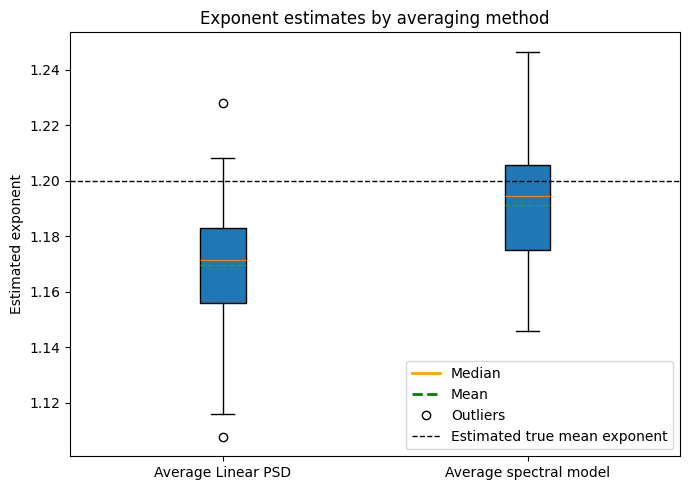

In [7]:
# Average the linear PSD
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_psd_2D(grid_range=[(1, 5)], exponent=exp_matrix, psd_average_space="linear", 
                                                              n_repeats=100, base_params=electrode_sim_params_full, plot=False, return_full=True)

exp1b_result1_psd_linear = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\Combined\exp1bresults1_psd_linear_exp_matrix_middle_-1-1.5.json", "w") as f:
    json.dump(exp1b_result1_psd_linear, f, indent=4)

# Average the SpecMod
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_specmod_2D(grid_range=[(1, 5)], exponent=exp_matrix, 
                                                              n_repeats=100, base_params=electrode_sim_params_full, plot=False, return_full=True)

exp1b_result2_specmod = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\Combined\exp1bresults2_specmod_exp_matrix_middle_-1-1.5.json", "w") as f:
    json.dump(exp1b_result2_specmod, f, indent=4)

# Loading summaries and combining into a single plot

summary_paths = [
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\Combined\exp1bresults1_psd_linear_exp_matrix_middle_-1-1.5.json",
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\Combined\exp1bresults2_specmod_exp_matrix_middle_-1-1.5.json"
]

labels = [
    "Average Linear PSD",
    "Average spectral model"
]

fig, ax = plot_summary_boxplots(
    summary_paths=summary_paths,
    labels=labels,
    true_mean_exp=np.mean(-exp_matrix)
)

fig.savefig(r"C:\Users\chloe\DissertationSimulations\Figures\1D electrodes\Combined plots\Combined sims\exp1b_combined_plot_1D_exp_matrix_middle_-1-1.5.png", dpi=300, bbox_inches="tight")

In [8]:
# Paired t-tests
with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\Combined\exp1bresults1_psd_linear_exp_matrix_middle_-1-1.5.json") as f:
    psd_linear_data = json.load(f)

with open( r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\Combined\exp1bresults2_specmod_exp_matrix_middle_-1-1.5.json") as f:
    spec_data = json.load(f)

psd_linear = np.array(psd_linear_data["all_distributions"][0])
spec = np.array(spec_data["all_distributions"][0])

t, p = ttest_rel(psd_linear, spec)
print(f"PSD - linear averaging vs Spectral model: t = {t:.3f}, p = {p:.5f}")

PSD - linear averaging vs Spectral model: t = -8.326, p = 0.00000


#### Experiment 1c
- 1D
- Linear variation - electrode exponents vary from -1 to -1.5 radially - "middle in"
- 5 electrodes
- Combined noise
- Average by TS, PSD and SpecMod. Do not produce plots, save outputs
- Load in JSON output summaries and plot a single combined plot

In [9]:
# Define exponent matrix
exp_matrix = generate_spatial_exponent_matrix(grid_shape=(1, 5), exp_min=-1, exp_max=-1.5, pattern="middle")
exp_matrix

array([[-1.5 , -1.25, -1.  , -1.25, -1.5 ]])

{'exponent': array([[-1.5 , -1.25, -1.  , -1.25, -1.5 ]]), 'psd_average_space': 'linear'}


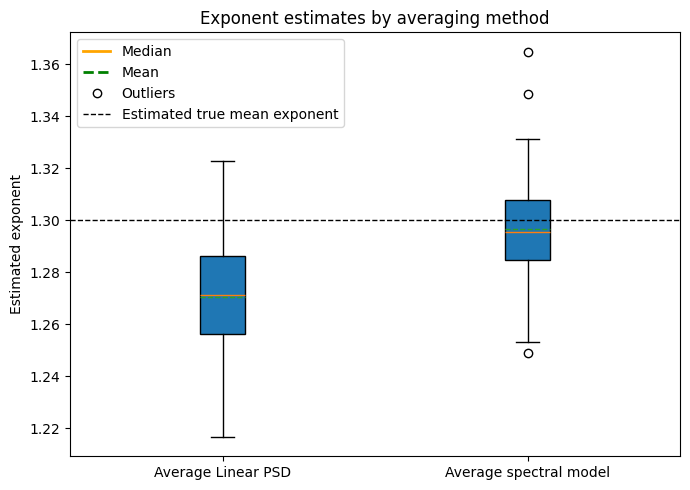

In [10]:
# Average the linear PSD
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_psd_2D(grid_range=[(1, 5)], exponent=exp_matrix, psd_average_space="linear", 
                                                              n_repeats=100, base_params=electrode_sim_params_full, plot=False, return_full=True)

exp1c_result1_psd_linear = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\Combined\exp1cresults1_psd_linear_exp_matrix_middle_-1-1.5.json", "w") as f:
    json.dump(exp1c_result1_psd_linear, f, indent=4)

# Average the SpecMod
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_specmod_2D(grid_range=[(1, 5)], exponent=exp_matrix, 
                                                              n_repeats=100, base_params=electrode_sim_params_full, plot=False, return_full=True)

exp1c_result2_specmod = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\Combined\exp1cresults2_specmod_exp_matrix_middle_-1-1.5.json", "w") as f:
    json.dump(exp1c_result2_specmod, f, indent=4)

# Loading summaries and combining into a single plot

summary_paths = [
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\Combined\exp1cresults1_psd_linear_exp_matrix_middle_-1-1.5.json",
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\Combined\exp1cresults2_specmod_exp_matrix_middle_-1-1.5.json"
]

labels = [
    "Average Linear PSD",
    "Average spectral model"
]

fig, ax = plot_summary_boxplots(
    summary_paths=summary_paths,
    labels=labels,
    true_mean_exp=np.mean(-exp_matrix)
)

fig.savefig(r"C:\Users\chloe\DissertationSimulations\Figures\1D electrodes\Combined plots\Combined sims\exp1c_combined_plot_1D_exp_matrix_middle_-1-1.5.png", dpi=300, bbox_inches="tight")

In [11]:
# Paired t-tests
with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\Combined\exp1cresults1_psd_linear_exp_matrix_middle_-1-1.5.json") as f:
    psd_linear_data = json.load(f)

with open( r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\Combined\exp1cresults2_specmod_exp_matrix_middle_-1-1.5.json") as f:
    spec_data = json.load(f)

psd_linear = np.array(psd_linear_data["all_distributions"][0])
spec = np.array(spec_data["all_distributions"][0])

t, p = ttest_rel(psd_linear, spec)
print(f"PSD - linear averaging vs Spectral model: t = {t:.3f}, p = {p:.5f}")

PSD - linear averaging vs Spectral model: t = -8.245, p = 0.00000
